In [8]:
import numpy as np
import matplotlib.pyplot as plt
import qil_helpers.Ben.General as Ben
import qil_helpers.Ben.Holeburning_analysis as HBA

#from qil_SpinHamiltonian.spin_hamiltonian import hamilFromYAML,eachElemFunc,transitionPixelPlot
import qil_SpinHamiltonian.spin_hamiltonian as spin
import qil_SpinHamiltonian.search as spinSearch

import matplotlib.colors as clr
import glob
import scipy.signal as sig
import re
import scipy as sp
import os
import pandas as pd
from copy import copy
from scipy import integrate,optimize

from IPython.display import display, Latex
from scipy.spatial.transform import Rotation

import plotly.graph_objects as go


{'Spin': {'Espin': '1/2', 'Ispin': '1/2'}, 'Rotation': {'rot': 'ZXZ'}, 'Hyperfine': {'A': 'np.diag([1,2,3])*1e9*h', 'A_rot': 'np.array([0,0,0])*np.pi/180'}, 'E_Zeeman': {'g': 'np.diag([10,-20,30])', 'g_rot': 'np.array([45,0,0])*np.pi/180'}, 'N_Zeeman': {'mu': '0.987'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'perp': 'np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])', 'perp_T': 'np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])'}}


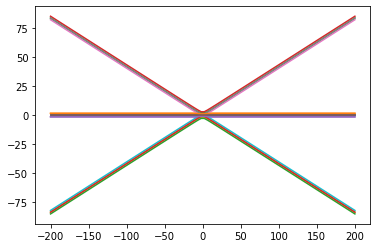

[[-5. 15.  0.]
 [15. -5.  0.]
 [ 0.  0. 30.]]


In [9]:
path="C:/Users/neb16/Documents/Uni/PHD/Experiments/Simulations/Spin_Hamiltonian/spin_hamiltonian/ion_params/"
gnd="Yb_CaWO.yml"
#gnd="Yb_YSO_site1_ground_alt.yml"
gnd="Yb_YSO_site1_ground.yml"
gnd="test.yml"

#gnd="Er_YSO_site1_ground.yml"
#gnd="Er_YSO_site1_ground_chen.yml"

ground=spin.hamilFromYAML(path+gnd)

#print(ground.gE)

odim = (ground.dim)//2
OS_par = np.eye(ground.dim)#np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])
OS_perp = np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])
OS_perp_T = np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])

br=200E-3
uvec=np.array([0,0,1])

R = ground.RE#np.asmatrix(Rotation.from_euler(rot,eval(ground.params['E_Zeeman']["g_rot"])).as_matrix())
uvec=R@uvec

pts=100
Bz=np.linspace(-br,br,pts)
Bzv=np.outer(uvec,Bz)

HG = np.array(ground.H)[np.newaxis,:,:]+ground.electronicZeeman(Bzv)#-ground.nuclearZeeman(Bzv)
FG,VG = ground.getEigFreq(HG)

OS=np.ones((pts,ground.dim**2))
OS = spin.TransitionStrength(VG,VG,OS_par,ground.dim)

FGS = FG

TGs=spin.eachElemFunc(FG,FG,axis=1)

plt.plot(Bz*1E3,TGs)
gdim=ground.dim
bidx=np.arange(0,OS.shape[1],gdim+1)
OS[:,bidx]=0
rng=1000E-3
#plt.ylim(-rng,rng)
#plt.ylim(0.840,0.940)
plt.show()

# print(Bt)
# g=np.mean(np.gradient(TGs.real,Bz,axis=0),axis=0)
# print(g)
print(ground.gE)

4


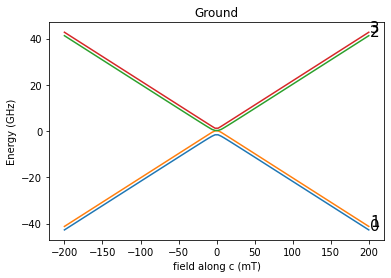

IndexError: tuple index out of range

In [10]:
I=1/2
print(gdim)
spins=np.arange(-2*I,I+4,2,dtype=np.int8)
Js=["-","+"]
dummy=r"$%s\left|%s\right>$"


spindex=[dummy%(Js[i>2*I],Js[i%2]) for i in range(ground.dim)]

#print(spindex)
plt.plot(Bz*1E3,FGS)
test=FGS[-1,:]
for i,t in enumerate(test):
#    plt.annotate(r"%s=%s"%(i,spindex[i]),(Bz[-1]*1E3,t),(0.1,0),fontsize=10,textcoords='offset fontsize')
    plt.annotate(r"%s"%(i),(Bz[-1]*1E3,t),(0.1,0),fontsize=15,textcoords='offset fontsize')



plt.title("Ground")
plt.ylabel("Energy (GHz)")
plt.xlabel("field along c (mT)")
plt.show()

labels=np.arange(gdim).astype('str')
a,b=spin.tilerepidx(gdim)
ZFHG = ground.H#+ground.electronicZeeman(Bt)-ground.nuclearZeeman(Bt)
ZFFG,_ = ground.getEigFreq(ZFHG)

ZFTGs=spin.eachElemFunc(ZFFG,ZFFG)

for i in range(a.shape[0]):
    print("%s: %s->%s"%(i,labels[a[i]],labels[b[i]]))
    print("\t %s GHz"%np.round(ZFTGs[i],3))


In [ ]:
#vx = ground.firstOrderEnergySensitivity(VG,ground.A[0])
i=0
Ri=np.linalg.inv(R)

#I=R@np.eye(3)@R
print(R)
I=np.eye(3)#@R.T
#I=Ri@np.eye(3)@Ri
print(I)
dH = ground.electronicZeeman(I)-ground.nuclearZeeman(I)
#dH = ground.electronicZeeman(np.eye(3))-ground.nuclearZeeman(np.eye(3))

dH=dH/(spin.h*1E9)
# print(ground.I)
pts=500
br=100E-3
Bz=np.linspace(-br,br,pts)
#print(I[:,i])
I=R@np.eye(3)
print(I)
#I=R@np.eye(3)#@R
#I=Ri@np.eye(3)#@Ri

print(I[:,i],np.linalg.norm(I[:,i]))
B=np.outer(I[:,i],Bz)


H = np.array(ground.H)[...,np.newaxis]+ground.electronicZeeman(B)-ground.nuclearZeeman(B)
FG,VG = ground.getEigFreq(H.T)

# print(np.matrix([1,1,1])@ground.I.T)
# print(ground.dH.shape,dH.shape)
# print(ground.dHx)
#print(dH[...,i])

#vx = ground.firstOrderEnergySensitivity(VG,ground.dHz)
#vx = spin.matrixElem(VG,dH[...,i],VG).T
#vx = spin.matrixElem(VG,dH[...,i],VG)
dV=ground.firstDerivative(VG,dH)
vx=dV@I[:,i]
#vx=np.rollaxis(vx,0,-1)
#ground.firstOrderEnergySensitivity(VG,dH[...,i])
plt.plot(Bz,FG)
plt.show()
plt.plot(Bz,vx)
#plt.show()
plt.gca().set_prop_cycle(None)

plt.plot(Bz,np.gradient(FG,Bz,axis=0),'--')
plt.show()

plt.plot(Bz,FG)
plt.gca().set_prop_cycle(None)

Fn=np.cumsum(vx,axis=0)*np.mean(np.diff(Bz))
idx=Ben.argnearest(Bz,0)
C=Fn[idx,:]-ZFFG
#print(Fn[:,idx].real,ZFFG)
#plt.show()
plt.plot(Bz,(Fn)-C,'--')

plt.show()


In [ ]:

def bulkCalc(G,B):
    HG = np.array(ground.H)[:,:,np.newaxis]+G.electronicZeeman(B)-G.nuclearZeeman(B)
    FG,VG = G.getEigFreq(HG.T)
    #OS = spin.TransitionStrength(VG,VG,np.eye(G.dim),G.dim)
    TGs=spin.eachElemFunc(FG,FG,ax=1).T
    Gp = []
    for l in range(3):
        v = G.firstOrderEnergySensitivity(VG,G.dH[...,l])
        Gp.append(v)
    Gp=np.array(Gp)
    Tps=spin.eachElemFunc(Gp,Gp,ax=1)
    # raise ValueError()
    return TGs,Tps,FG



In [ ]:
pts=50
r=1E-2#0.1E-3
thetas,phis=np.meshgrid(np.linspace(0,np.pi,pts),np.linspace(0,2*np.pi,pts))
x=(r*np.sin(thetas)*np.cos(phis)).flatten()
y=(r*np.sin(thetas)*np.sin(phis)).flatten()
z=(r*np.cos(thetas)).flatten()
vec=np.vstack([x,y,z])
direction=np.array([1,1,1])
idx=np.squeeze(np.where(np.dot(direction,vec)>=0))
idx=np.arange(0,vec.shape[-1],1)
vec=vec[:,idx]


In [ ]:

B=vec
Bu=np.linalg.norm(B,axis=0)#np.sqrt(B.dot(B).T)
TGs,Tps,FG=bulkCalc(ground,vec)
pvals=TGs[3,:].real

In [ ]:
off=1.2*r
axis=["D1","D2","c"]
#I=R@np.eye(3)#@R#.T#@R

def axisSystem(I,axis,col='rgb(0,0,0)',**kwargs):
    plot= [go.Scatter3d( x = [-off*0*I[0,i],off*I[0,i]],
                       y = [-off*0*I[1,i],off*I[1,i]],
                       z = [-off*0*I[2,i],off*I[2,i]],
                       line = dict( color = col,
                                    width = 6),
                        text=l,
                        mode='lines'
                     ) for i,l in enumerate(axis)]
    labels=[dict(
            x=off*I[0,i],
            y=off*I[1,i],
            z=off*I[2,i],
            text=l,
            showarrow=False
        ) for i,l in enumerate(axis)]
    return plot,labels

bcoords,blabels=axisSystem(np.eye(3),axis)
ecoords,elabels=axisSystem(R@np.eye(3),["D1\'","D2\'","c\'"],col="rgb(0,0,1)")

fig = go.Figure(data=[go.Surface(
    x=x.reshape((pts,pts)),
    y=y.reshape((pts,pts)),
    z=z.reshape((pts,pts)),
    #surfacecolor=np.ones((pts,pts)),
    surfacecolor=pvals.reshape((pts,pts)),
    colorscale='viridis',
    opacity=1,
    ),*bcoords,*ecoords])

fig.update_layout(
    scene=dict(annotations=blabels+elabels))
fig.show()


In [ ]:

raise ValueError("Stop")

In [ ]:
class cSpinSearch:
    def __init__(self,hamil):
        self.H=hamil
        self.HS=np.array(self.H.H)[:,:,np.newaxis]
    def updateB(self,B):
        self.HG = self.HS+self.H.electronicZeeman(B)#-self.H.nuclearZeeman(B)
        self.F,self.V = self.H.getEigFreq(self.HG.T)
    def T(self):
        return spin.eachElemFunc(self.F,self.F,ax=1)        
    def jacobian(self):
        Gp = []
        for l in range(3):
            v = self.H.firstOrderEnergySensitivity(self.V,self.H.A[l])
            Gp.append(v)
        Gp=np.array(Gp)
        Tps=spin.eachElemFunc(Gp,Gp,ax=1)
        return Tps.T
    def hessian(self):
        Hx=self.H.A[0]
        Hy=self.H.A[1]
        Hz=self.H.A[2]
        S=self.H.curvatureCalculationVec(Hx,Hy,Hz,self.V,self.F)
        S=spin.eachElemFunc(S,S,ax=1)
        return S


In [ ]:
pts=100
r=50E-3#0.1E-3
thetas=np.pi/6
rs,phis=np.meshgrid(np.linspace(0,r,pts),np.linspace(0,2*np.pi,pts))
x=(rs*np.sin(thetas)*np.cos(phis)).flatten()
y=(rs*np.sin(thetas)*np.sin(phis)).flatten()
z=(rs*np.cos(thetas)).flatten()
B=np.vstack([x,y,z])



GS=cSpinSearch(ground)

GS.updateB(B)
J=GS.jacobian()
S=GS.hessian()
print(J.shape)

print(S.shape)
#print(J[:,1,0],J.T[0,1,:])
#print(.shape)
Ts=GS.T()
#T=Ts[:,0]
fig = go.Figure(data=[go.Surface(
    x=x.reshape((pts,pts)),
    y=y.reshape((pts,pts)),
    z=Ts[:,i].reshape((pts,pts)),
    #surfacecolor=np.ones((pts,pts)),
    surfacecolor=Ts[:,i].reshape((pts,pts)),
    colorscale='viridis',
    opacity=1,
    ) for i in range(16)])
fig.show()

#print(S.conj()[0,0,...])

In [ ]:
%%script False
pts=50
B0=1E-2#0.1E-3
j=6
fCav=3

thetas,phis=np.meshgrid(np.linspace(0,np.pi,pts),np.linspace(0,2*np.pi,pts))
x=(1*np.sin(thetas)*np.cos(phis)).flatten()
y=(1*np.sin(thetas)*np.sin(phis)).flatten()
z=(1*np.cos(thetas)).flatten()
uvec=np.vstack([x,y,z])
B0=B0*uvec#np.repeat(B0,uvec.shape[-1])



GS=cSpinSearch(ground)
GS.updateB(B)
def tOptFunc(B):
    GS.updateB(B)
    Ts=GS.T()
    return Ts[:,j]-fCav
jac=lambda B: GS.jacobian()[:,j,:]

B=optimize.least_squares(tOptFunc,B0,jac)#spinSearch.lsMatch(fCav,uvec,lambda B: tOptFunc(B),B0,jac=jac)
fig = go.Figure(data=[go.Surface(
    x=(B*x*1E3).reshape((pts,pts)),
    y=(B*y*1E3).reshape((pts,pts)),
    z=(B*z*1E3).reshape((pts,pts)),
    #surfacecolor=np.ones((pts,pts)),
    surfacecolor=(B).reshape((pts,pts)),
    colorscale='RdBu',
    opacity=1,
    )])
fig.show()

In [ ]:
pts=50
B0=1E-2#0.1E-3
j=6
fCav=3

thetas,phis=np.meshgrid(np.linspace(0,np.pi,pts),np.linspace(0,2*np.pi,pts))
x=(1*np.sin(thetas)*np.cos(phis)).flatten()
y=(1*np.sin(thetas)*np.sin(phis)).flatten()
z=(1*np.cos(thetas)).flatten()
uvec=np.vstack([x,y,z])
B=B0*uvec#np.repeat(B0,uvec.shape[-1])
GS=cSpinSearch(ground)
GS.updateB(B)
for i in range(10):
    GS.updateB(B)
    V=GS.jacobian()[:,j,...]
    C=GS.hessian()[:,j,...]
    S=np.matmul(np.linalg.inv(C),V[...,None]).real
    #S=np.matmul(C,V[...,None]).real
    S=np.squeeze(S).T
    B=B-2*S

#B=B.real


In [ ]:

fig = go.Figure(data=go.Scatter3d(
    x=(B[0,:]*1E3),
    y=(B[1,:]*1E3),
    z=(B[2,:]*1E3),
    mode='markers',
    ))

fig.show()


print(C[0,...])
print(V[0,...])
print(S[0,...])


# V=np.ones((10,3))
# C=np.repeat(np.arange(9).reshape((3,3))[np.newaxis,:,:],10,0)


# print(V[0,:])
# print(C[0,...])
# #S=np.einsum('kdd,kd->kd',C,V)
# S=np.matmul(C,V[...,None])
# S=np.squeeze(S)
# print(S.shape)
# print(S[0,...])



In [ ]:
B0=1E-3
pts=20
r,thetas,phis=np.meshgrid(np.linspace(0,B0,pts),np.linspace(0,np.pi,pts),np.linspace(0,2*np.pi,pts))
x=(r*np.sin(thetas)*np.cos(phis)).flatten()
y=(r*np.sin(thetas)*np.sin(phis)).flatten()
z=(r*np.cos(thetas)).flatten()
B=np.vstack([x,y,z])
#B=B0*uvec#np.repeat(B0,uvec.shape[-1])
GS=cSpinSearch(ground)
GS.updateB(B)
V=GS.jacobian()[:,j,...]
# C=GS.hessian()[:,j,...]


F=GS.F[:,j,...].reshape((pts,pts,pts))
print(F.shape)

Vn=np.array([np.gradient(F,axis=0),np.gradient(F,axis=1),np.gradient(F,axis=2)])
Vn=np.roll(Vn,0,-1)
Vnn=Vn.reshape(-1,3)
print(np.mean(V-Vnn))

In [ ]:
raise ValueError("Stop")

In [ ]:

B0=1E-2#1E-3
fCav=3#3.25#3.6#3.33
tidx=105

print("Zero field splitting %s GHz"%np.round(ZFTGs[tidx],3))

pts=35
thetas,phis=np.meshgrid(np.linspace(0,np.pi,pts),np.linspace(0,2*np.pi,pts))
x=(np.sin(thetas)*np.cos(phis)).flatten()
y=(np.sin(thetas)*np.sin(phis)).flatten()
z=(np.cos(thetas)).flatten()
uvec=np.vstack([x,y,z])
B=np.repeat(B0,uvec.shape[-1])
Kp=0.1
Ts=tOptFunc(tidx,B*uvec)

B=spinSearch.lsMatch(fCav,uvec,lambda B: tOptFunc(tidx,B),1/Ts)



In [ ]:
Ts,Tps,FG=bulkCalc(ground,B*uvec)
col=Tps[tidx,:].real

B=B.real
fig = go.Figure(data=[go.Surface(
    x=(B*x*1E3).reshape((pts,pts)),
    y=(B*y*1E3).reshape((pts,pts)),
    z=(B*z*1E3).reshape((pts,pts)),
    #surfacecolor=np.ones((pts,pts)),
    surfacecolor=(col).reshape((pts,pts)),
    colorscale='RdBu',
    opacity=1,
    )])

#fig.update_traces(colorbar_title_text = r"$|\delta f \cdot B|$")
fig.update_traces(colorbar_title_text = "gradient along unit vector (GHz/T)")

fig.update_layout(title_text="Isosurface to match %s GHz cavity"%fCav)
fig.show()
fig = go.Figure(data=[go.Surface(
    x=(B*x*1E3).reshape((pts,pts)),
    y=(B*y*1E3).reshape((pts,pts)),
    z=(B*z*1E3).reshape((pts,pts)),
    #surfacecolor=np.ones((pts,pts)),
    surfacecolor=(Ts[tidx,:]).reshape((pts,pts)),
    colorscale='RdBu',
    opacity=1,
    )])
fig.show()

plt.pcolormesh(thetas,phis,B.reshape((pts,pts))*1E3)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\phi$")
plt.title("Field (mT)")
plt.colorbar()
plt.show()
plt.pcolormesh(thetas*180/np.pi,phis*180/np.pi,(Tps[tidx,:]).real.reshape((pts,pts)),cmap=plt.cm.RdBu)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\phi$")
plt.title("Field gradient (GHz/T)")

plt.colorbar()
plt.show()